In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# paths
paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "Gemini":   "pred_vs_true_score_gemini.csv",
    "GPT-4o":   "pred_vs_true_score_gpt4o.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv",
}

def spearman_for_file(path):
    df = pd.read_csv(path, usecols=["y_true", "y_pred"])
    # robust to strings/NaNs
    df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["y_true","y_pred"])
    rho, p = spearmanr(df["y_true"].values, df["y_pred"].values)
    return len(df), rho, p

rows = []
for name, path in paths.items():
    n, rho, p = spearman_for_file(path)
    rows.append({"Model": name, "n": n, "Spearman_rho": rho, "p_value": p})

summary = pd.DataFrame(rows).set_index("Model").sort_values("Spearman_rho", ascending=False)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))


             n  Spearman_rho  p_value
Model                                
LLM-Mean  9872        0.8934   0.0000
Gemini    9872        0.8004   0.0000
GPT-4o    9872        0.7687   0.0000
DeepSeek  9872        0.7446   0.0000


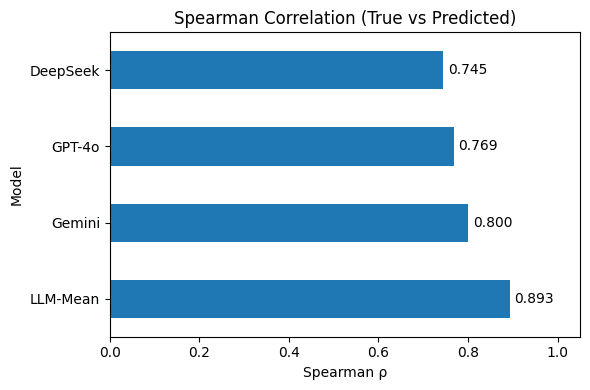

In [3]:
# Bar plot (sorted already)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
summary["Spearman_rho"].plot(kind="barh")
plt.xlabel("Spearman ρ")
plt.title("Spearman Correlation (True vs Predicted)")
for i, v in enumerate(summary["Spearman_rho"].values):
    plt.text(v + 0.01*np.sign(v), i, f"{v:.3f}", va="center")
plt.xlim(min(0, summary["Spearman_rho"].min()-0.05), 1.05)
plt.tight_layout()
plt.show()


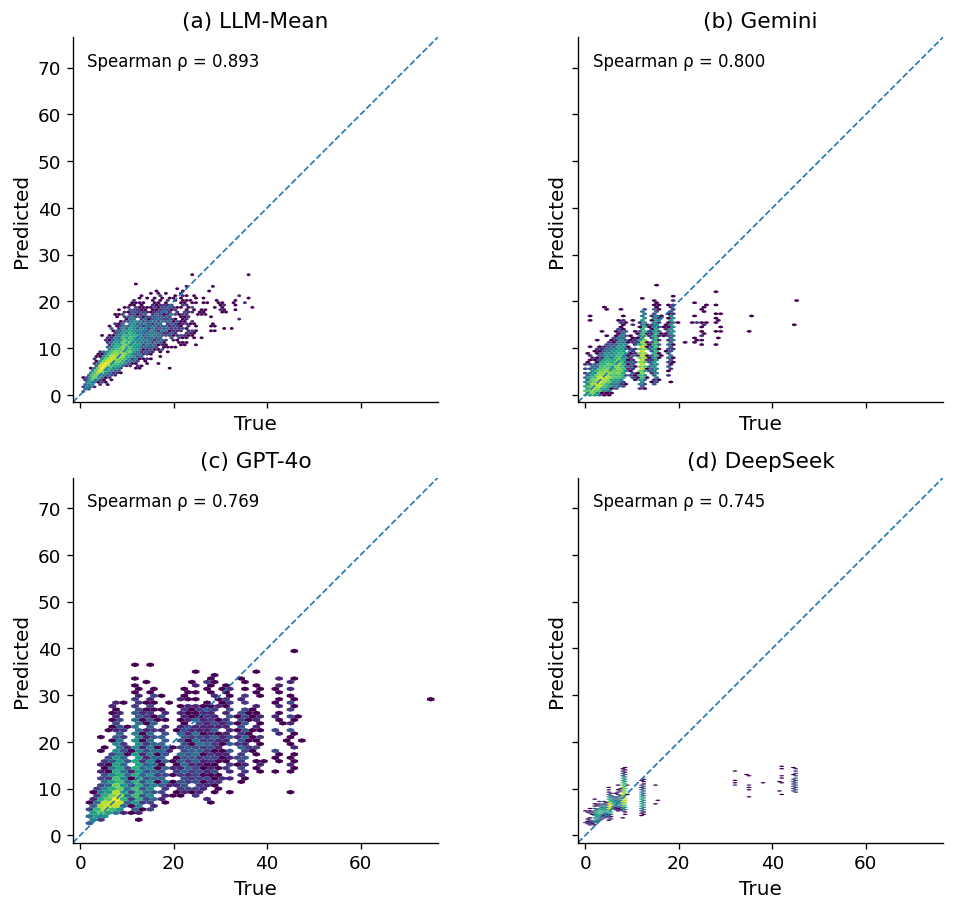

In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Aesthetics
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.frameon": False,
})

paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "Gemini":   "pred_vs_true_score_gemini.csv",
    "GPT-4o":   "pred_vs_true_score_gpt4o.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv",
}

def load_xy(path):
    df = pd.read_csv(path, usecols=["y_true", "y_pred"])
    df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["y_true","y_pred"])
    return df["y_true"].to_numpy(), df["y_pred"].to_numpy()

# Cache + common limits
cache, lo, hi = {}, np.inf, -np.inf
for name, path in paths.items():
    yt, yp = load_xy(path)
    cache[name] = (yt, yp)
    lo = min(lo, yt.min(), yp.min())
    hi = max(hi, yt.max(), yp.max())
margin = 0.02 * (hi - lo)
lo, hi = lo - margin, hi + margin

# Figure
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
axes = axes.ravel()
panel_tags = ["a", "b", "c", "d"]

for ax, tag, (name, (yt, yp)) in zip(axes, panel_tags, cache.items()):
    # density without colorbar
    ax.hexbin(yt, yp, gridsize=45, bins="log", linewidths=0)  # cmap default is fine

    # 45° reference
    ax.plot([lo, hi], [lo, hi], ls="--", lw=1)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted")

    rho, _ = spearmanr(yt, yp)
    ax.text(0.04, 0.96, f"Spearman ρ = {rho:.3f}",
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.3"))

    ax.set_title(f"({tag}) {name}")

plt.suptitle("", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])   # full width now that the colorbar is gone
plt.savefig("correlation_panels_no_cbar.png", bbox_inches="tight")
plt.savefig("correlation_panels_no_cbar.pdf", bbox_inches="tight")
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========== Plot Style ==========
sns.set(style="whitegrid", font_scale=1.2)
palette = "tab10"

# ========== Load CSVs ==========
paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "Gemini":   "pred_vs_true_score_gemini.csv",
    "GPT-4o":   "pred_vs_true_score_gpt4o.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv"
}

df_list = []
for model_name, path in paths.items():
    df = pd.read_csv(path, usecols=["y_true", "y_pred"])
    df["Model"] = model_name
    df = df.dropna()
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)


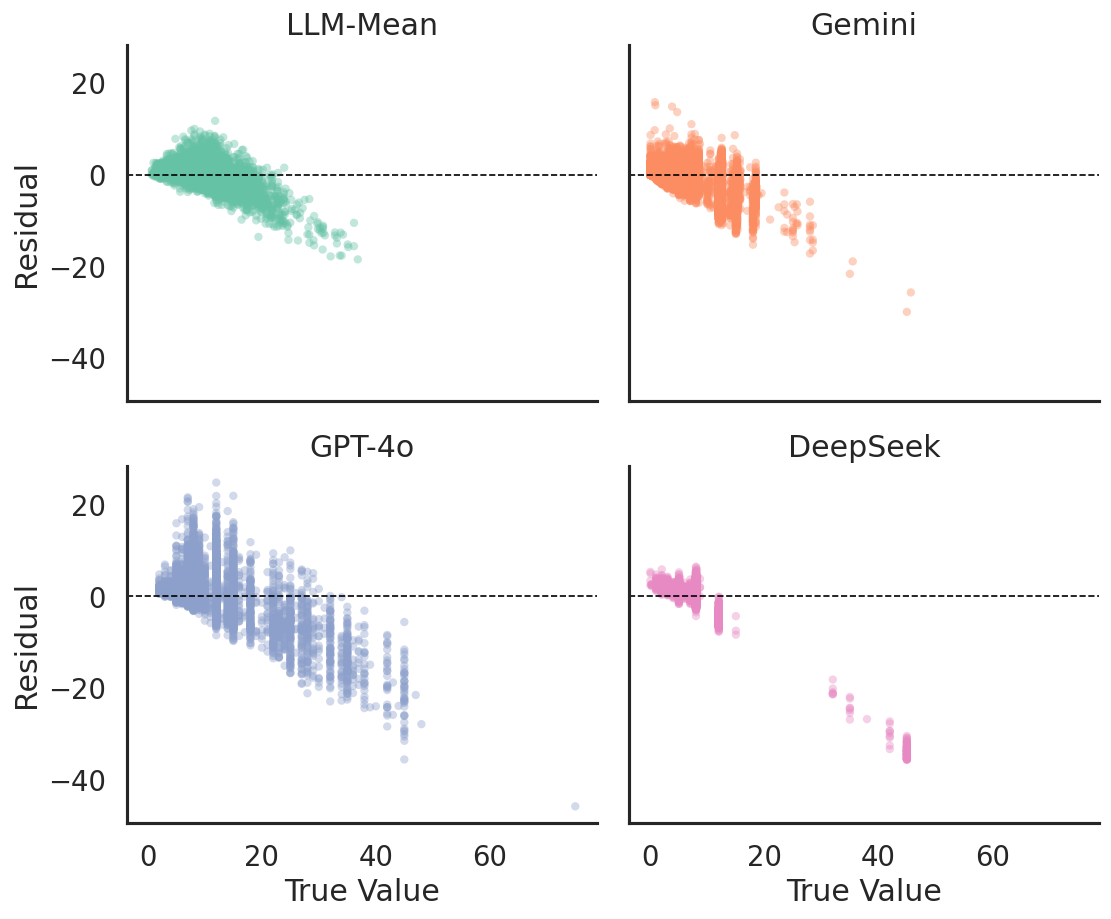

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute residuals
df_all["residual"] = df_all["y_pred"] - df_all["y_true"]

# Set plain theme (white background, no grids)
sns.set(style="white", context="talk", palette="Set2")

# Create facet plot
g = sns.FacetGrid(
    df_all,
    col="Model",
    col_wrap=2,
    height=4,
    aspect=1.2,
    hue="Model",
    palette="Set2"
)

# Scatterplot of residuals
g.map_dataframe(
    sns.scatterplot,
    x="y_true",
    y="residual",
    s=25,
    alpha=0.4,
    edgecolor="none"
)

# Add horizontal line at 0
for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_facecolor("white")  # explicit background

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("True Value", "Residual")

# Clean layout
g.tight_layout()
g.savefig("residual_facet_plot_plain.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
import pandas as pd

# ======================
# Residual summary stats
# ======================
residual_stats = (
    df_all
    .groupby("Model")
    .agg(
        n_samples=("residual", "count"),
        mean_residual=("residual", "mean"),
        std_residual=("residual", "std"),
        median_residual=("residual", "median"),
        max_abs_residual=("residual", lambda x: x.abs().max())
    )
    .reset_index()
)

# Save stats to CSV
residual_stats.to_csv("residual_summary_stats.csv", index=False)

# ======================
# Optional: Save sample of residuals
# ======================
residual_samples = (
    df_all[["Model", "y_true", "y_pred", "residual"]]
    .groupby("Model")
    .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))
    .reset_index(drop=True)
)

residual_samples.to_csv("residual_sample_per_model.csv", index=False)

/tmp/slurmtmp.37263462/ipykernel_2156497/511135159.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))


In [16]:
residual_stats

,Model,n_samples,mean_residual,std_residual,median_residual,max_abs_residual
0,DeepSeek,9872,0.333233,3.623030,0.897333,35.632242
1,GPT-4o,9872,0.285060,4.830025,0.479308,45.777790
2,Gemini,9872,-1.424348,3.158617,-0.957135,29.882651
3,LLM-Mean,9872,0.484360,2.250905,0.773636,18.427908


Spearman correlations (Residual vs Predicted):
LLM-Mean: 0.055
Gemini: -0.034
GPT-4o: 0.218
DeepSeek: 0.048


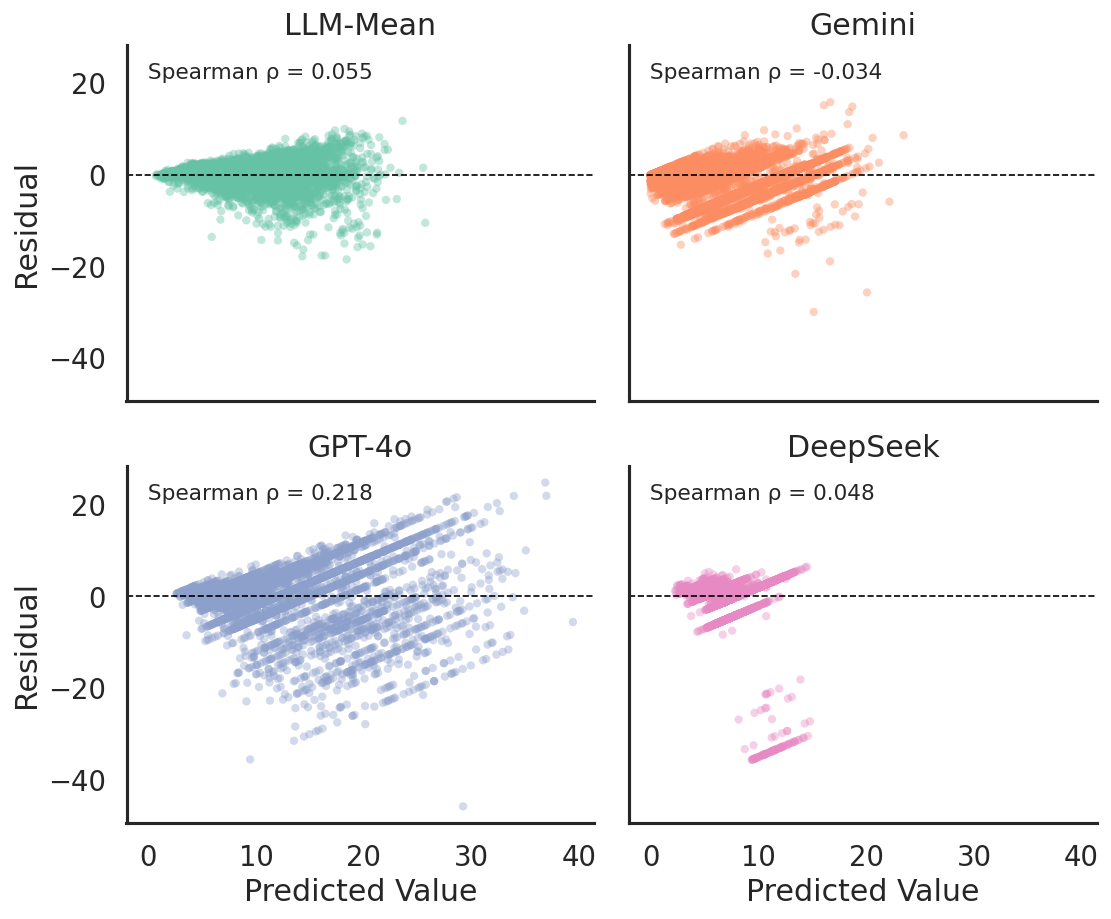

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Compute residuals
df_all["residual"] = df_all["y_pred"] - df_all["y_true"]

# ---- Compute Spearman correlation (residual vs predicted) ----
corr_dict = {}
for model in df_all["Model"].unique():
    temp = df_all[df_all["Model"] == model]
    corr, _ = spearmanr(temp["y_pred"], temp["residual"])
    corr_dict[model] = corr

print("Spearman correlations (Residual vs Predicted):")
for m, c in corr_dict.items():
    print(f"{m}: {c:.3f}")

# ---- Plot settings ----
sns.set(style="white", context="talk", palette="Set2")

# Create facet plot
g = sns.FacetGrid(
    df_all,
    col="Model",
    col_wrap=2,
    height=4,
    aspect=1.2,
    hue="Model",
    palette="Set2"
)

# Scatterplot
g.map_dataframe(
    sns.scatterplot,
    x="y_pred",
    y="residual",
    s=25,
    alpha=0.4,
    edgecolor="none"
)

# Add horizontal line + correlation text
for ax, model in zip(g.axes.flat, g.col_names):
    # Zero residual line
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_facecolor("white")

    # Annotation: Spearman correlation
    corr_val = corr_dict[model]
    ax.text(
        0.03, 0.95,
        f" Spearman ρ = {corr_val:.3f}",
        transform=ax.transAxes,
        fontsize=13,
        verticalalignment="top"
    )

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Predicted Value", "Residual")

# Clean layout
g.tight_layout()
g.savefig("residual_vs_predicted_simple_corr.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/slurmtmp.37263462/ipykernel_2156497/525136776.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=r2_df, x="Model", y="R2_mean", palette="pastel", capsize=0.15, ci=None)
/tmp/slurmtmp.37263462/ipykernel_2156497/525136776.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=r2_df, x="Model", y="R2_mean", palette="pastel", capsize=0.15, ci=None)


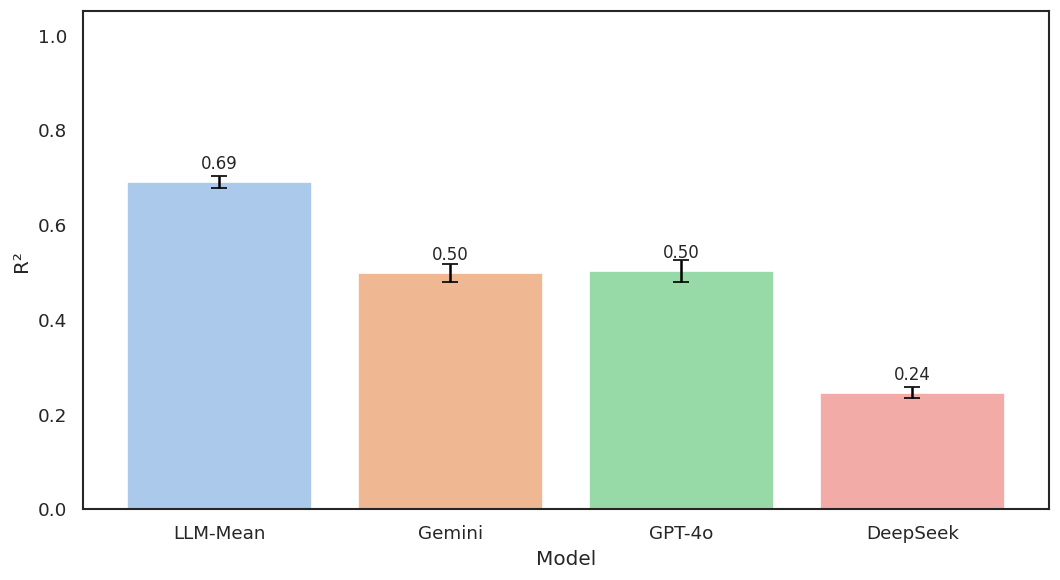

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

# === Bootstrapped R² ===
def bootstrap_r2(y_true, y_pred, n_boot=1000):
    r2s = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        r2s.append(r2_score(y_true[idx], y_pred[idx]))
    return np.mean(r2s), np.std(r2s)

# === Compute per model ===
rows = []
for model in df_all["Model"].unique():
    sub = df_all[df_all["Model"] == model]
    yt = sub["y_true"].to_numpy()
    yp = sub["y_pred"].to_numpy()
    mean_r2, std_r2 = bootstrap_r2(yt, yp)
    rows.append({
        "Model": model,
        "R2_mean": mean_r2,
        "R2_std": std_r2,
        "R2_CI_low": mean_r2 - 1.96 * std_r2,
        "R2_CI_high": mean_r2 + 1.96 * std_r2
    })

r2_df = pd.DataFrame(rows)

# === Plot with error bars ===
plt.figure(figsize=(9, 5))
sns.barplot(data=r2_df, x="Model", y="R2_mean", palette="pastel", capsize=0.15, ci=None)
plt.errorbar(
    x=np.arange(len(r2_df)),
    y=r2_df["R2_mean"],
    yerr=1.96 * r2_df["R2_std"],
    fmt='none',
    c='black',
    capsize=5
)

# Add numeric labels
for i, row in r2_df.iterrows():
    plt.text(i, row["R2_mean"] + 0.02, f"{row['R2_mean']:.2f}", ha='center', va='bottom', fontsize=10)

plt.title("", fontsize=14)
plt.ylabel("R²")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("r2_score_barplot_with_ci.png", dpi=300)
plt.show()


In [31]:
r2_df

,Model,R2_mean,R2_std,R2_CI_low,R2_CI_high
0,LLM-Mean,0.688947,0.006458,0.676290,0.701605
1,Gemini,0.496723,0.008394,0.480271,0.513175
2,GPT-4o,0.502484,0.011070,0.480787,0.524181
3,DeepSeek,0.245157,0.006243,0.232922,0.257393


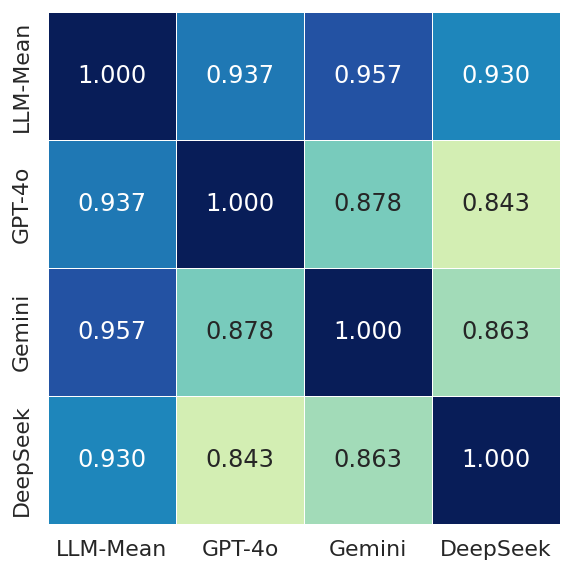

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load predictions ---
paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "GPT-4o": "pred_vs_true_score_gpt4o.csv",
    "Gemini": "pred_vs_true_score_gemini.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv",
}

df_predictions = pd.DataFrame()
for model, path in paths.items():
    df = pd.read_csv(path, usecols=["y_pred"])
    df_predictions[model] = df["y_pred"]

df_predictions = df_predictions.dropna()

# --- Compute Spearman correlation ---
corr = df_predictions.corr(method="spearman")

# --- Plot full heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.8,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar=False  # Hide the sidebar
)

plt.title("")
plt.tight_layout()
plt.savefig("model_prediction_correlation_full_heatmap.png", dpi=300)
plt.show()


/tmp/slurmtmp.37263462/ipykernel_2156497/4101186458.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


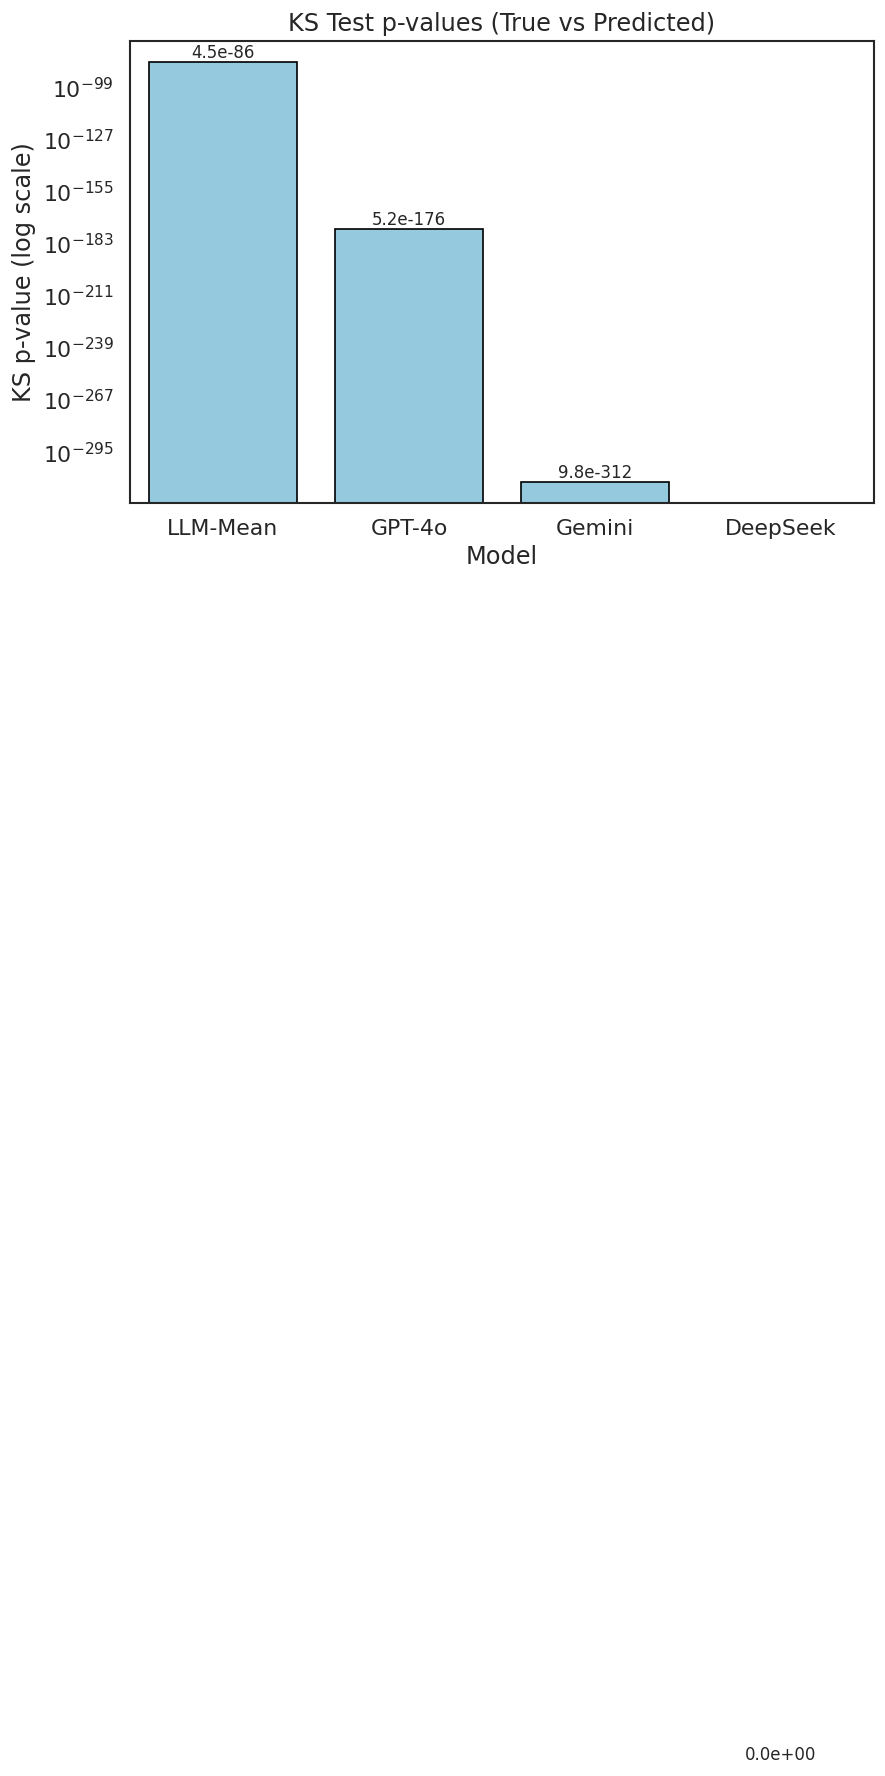

In [40]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load predictions ---
paths = {
    "LLM-Mean": "pred_vs_true_llm_mean_score.csv",
    "GPT-4o": "pred_vs_true_score_gpt4o.csv",
    "Gemini": "pred_vs_true_score_gemini.csv",
    "DeepSeek": "pred_vs_true_score_deepseek.csv",
}

results = []
for model, path in paths.items():
    df = pd.read_csv(path, usecols=["y_true", "y_pred"]).dropna()
    ks_stat, pval = ks_2samp(df["y_true"], df["y_pred"])
    results.append({"Model": model, "KS_statistic": ks_stat, "KS_pvalue": pval})

ks_df = pd.DataFrame(results)

# --- Plot KS p-values (Log scale) ---
plt.figure(figsize=(8, 5))
sns.barplot(data=ks_df, x="Model", y="KS_pvalue", color="skyblue", edgecolor="black")

# Add numeric labels above bars
for i, row in ks_df.iterrows():
    plt.text(i, row["KS_pvalue"] * 1.1, f"{row['KS_pvalue']:.1e}", ha="center", va="bottom", fontsize=10)

plt.yscale("log")
plt.ylabel("KS p-value (log scale)")
plt.title("")
plt.tight_layout()
plt.savefig("ks_test_pvalues_logscale.png", dpi=300)
plt.show()


In [45]:
ks_df

,Model,KS_statistic,KS_pvalue
0,LLM-Mean,0.141106,4.513644e-86
1,GPT-4o,0.201682,5.225248e-176
2,Gemini,0.267828,9.781042e-312
3,DeepSeek,0.349878,0.000000e+00


/tmp/slurmtmp.37263462/ipykernel_2156497/3823965219.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/slurmtmp.37263462/ipykernel_2156497/3823965219.py:10: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.barplot(
/tmp/slurmtmp.37263462/ipykernel_2156497/3823965219.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


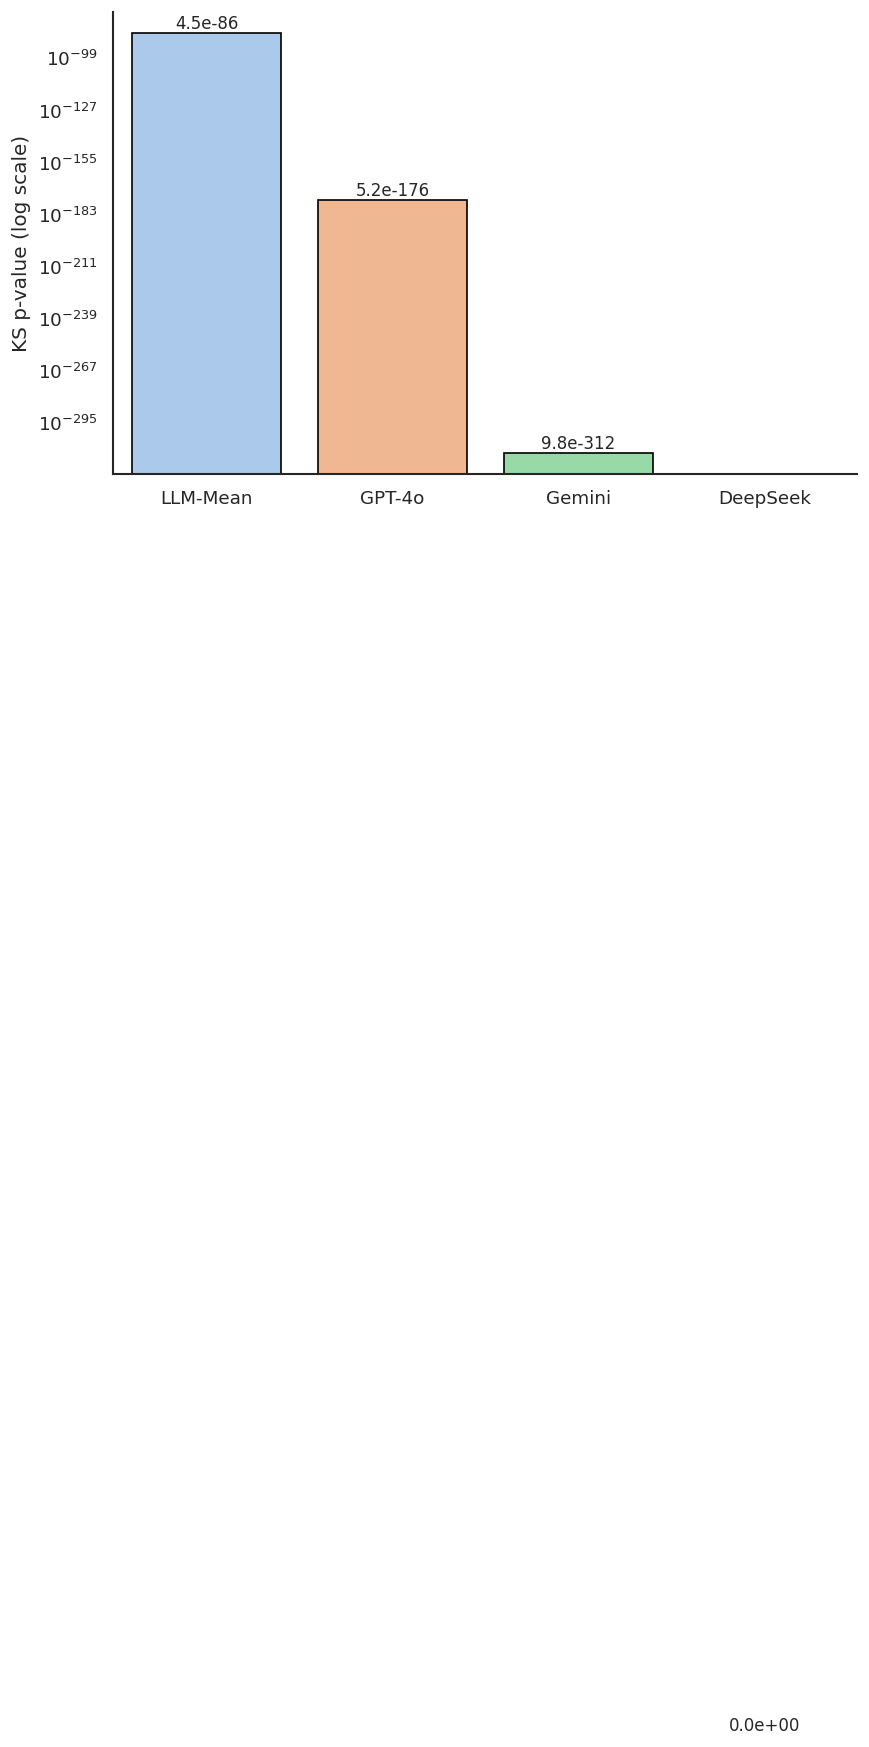

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plain white background
sns.set(style="white")  # removes grid
custom_colors = sns.color_palette("pastel")  # soft pastel color palette

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=ks_df,
    x="Model",
    y="KS_pvalue",
    palette=custom_colors,
    edgecolor="black"
)

# Add p-value labels
for i, row in ks_df.iterrows():
    plt.text(
        i, row["KS_pvalue"] * 1.15,
        f"{row['KS_pvalue']:.1e}",
        ha="center", va="bottom", fontsize=10
    )

# Final touches
plt.yscale("log")
plt.ylabel("KS p-value (log scale)")
plt.xlabel("")
plt.title("", fontsize=13, weight="bold", pad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove borders/spines
sns.despine()  # removes top and right borders

plt.tight_layout()
plt.savefig("ks_test_pvalues_logscale_plain.png", dpi=300)
plt.savefig("ks_test_pvalues_logscale_plain.pdf")
plt.show()


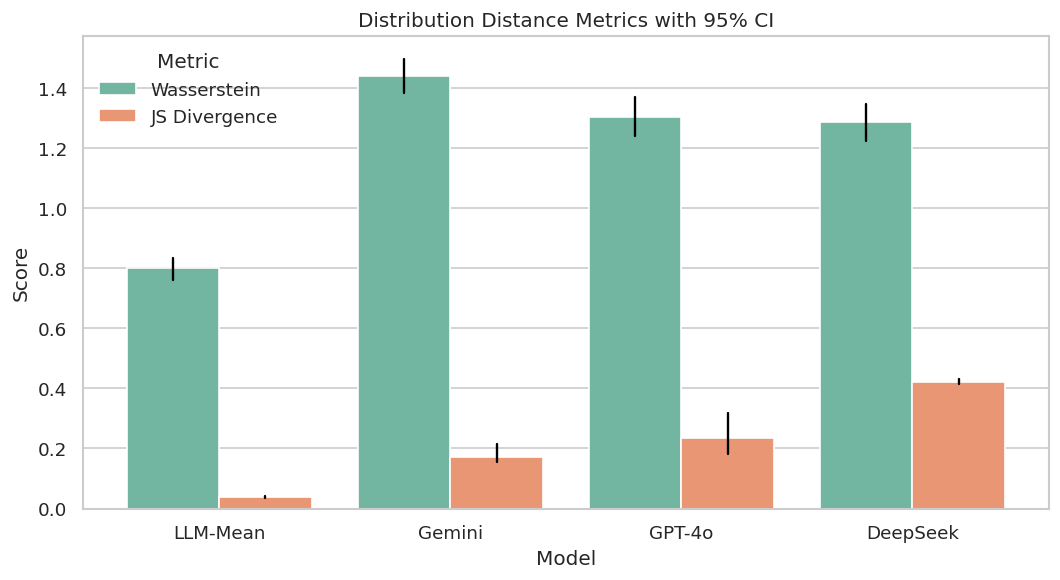

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, entropy
from scipy.spatial.distance import jensenshannon
from sklearn.utils import resample

# --------- Helper: Jensen-Shannon Divergence ----------
def compute_js_divergence(p, q, bins=100):
    """JS divergence between two continuous distributions using histogram bins."""
    hist_p, bin_edges = np.histogram(p, bins=bins, density=True)
    hist_q, _ = np.histogram(q, bins=bin_edges, density=True)
    
    hist_p += 1e-12  # avoid log(0)
    hist_q += 1e-12

    m = 0.5 * (hist_p + hist_q)
    js = 0.5 * (entropy(hist_p, m) + entropy(hist_q, m))
    return js

# --------- Bootstrap CI Function ----------
def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=1000, alpha=0.05):
    stats = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        stats.append(metric_func(y_true[idx], y_pred[idx]))
    lower = np.percentile(stats, 100 * alpha / 2)
    upper = np.percentile(stats, 100 * (1 - alpha / 2))
    return np.mean(stats), lower, upper

# --------- Example: df_all required ---------
# Your dataframe must include: 'Model', 'y_true', 'y_pred'
# Example structure (uncomment if you need to simulate):
# models = ["ModelA", "ModelB"]
# df_all = pd.concat([
#     pd.DataFrame({
#         "Model": model,
#         "y_true": np.random.normal(10, 2, 1000),
#         "y_pred": np.random.normal(10, 2, 1000) + np.random.normal(0, 1, 1000)
#     }) for model in models
# ])

# --------- Compute Bootstrapped Distances ----------
boot_results = []
for model in df_all["Model"].unique():
    subset = df_all[df_all["Model"] == model]
    y_true = subset["y_true"].values
    y_pred = subset["y_pred"].values

    # Wasserstein Distance
    w_mean, w_low, w_high = bootstrap_metric_ci(y_true, y_pred, wasserstein_distance)

    # Jensen-Shannon Divergence
    js_mean, js_low, js_high = bootstrap_metric_ci(
        y_true, y_pred, lambda a, b: compute_js_divergence(a, b)
    )

    # Append
    boot_results.extend([
        {"Model": model, "Metric": "Wasserstein", "Value": w_mean, "CI_low": w_low, "CI_high": w_high},
        {"Model": model, "Metric": "JS Divergence", "Value": js_mean, "CI_low": js_low, "CI_high": js_high}
    ])

# --------- Create DataFrame ---------
plot_df = pd.DataFrame(boot_results)


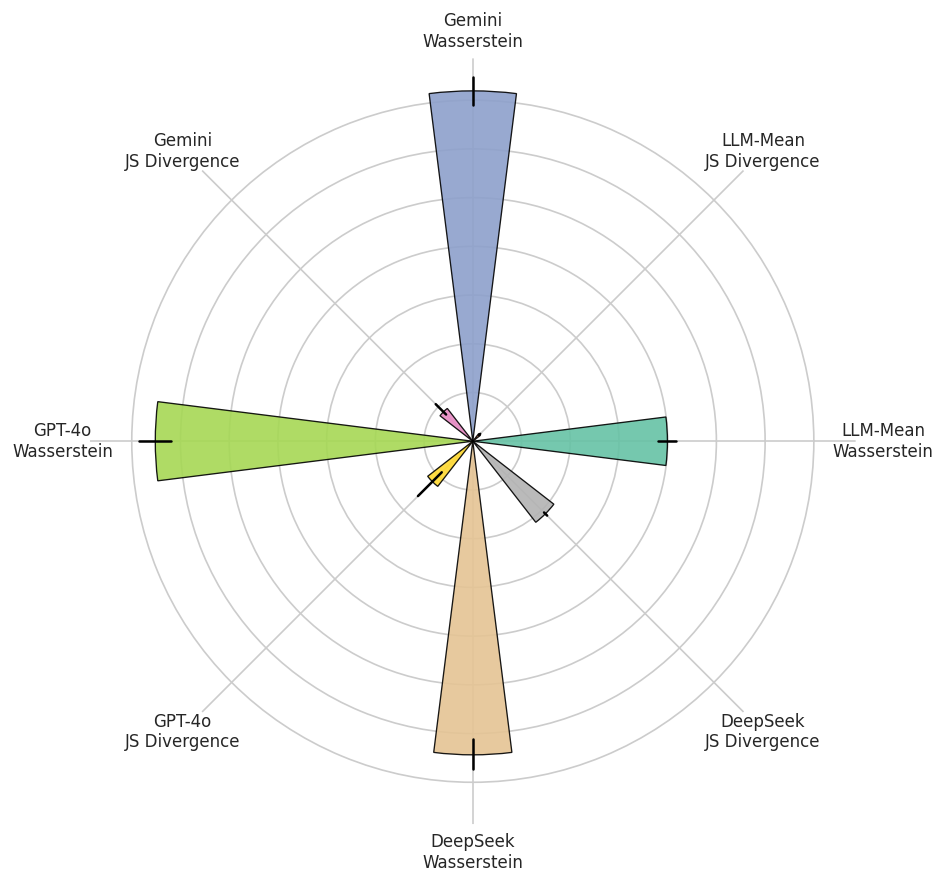

In [48]:
import numpy as np

# Prepare circular plot data
circular_df = plot_df.copy()
circular_df["Angle"] = np.linspace(0, 2 * np.pi, len(circular_df), endpoint=False)
circular_df["Label"] = circular_df["Model"] + "\n" + circular_df["Metric"]

# Plot
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

bars = ax.bar(
    circular_df["Angle"],
    circular_df["Value"],
    width=0.25,
    color=sns.color_palette("Set2", len(circular_df)),
    alpha=0.9,
    edgecolor='black',
    linewidth=0.8
)

# Add error bars
for i, row in circular_df.iterrows():
    theta = row["Angle"]
    r = row["Value"]
    ax.plot([theta, theta], [row["CI_low"], row["CI_high"]], color="black", lw=1.5)

# Aesthetic
ax.set_xticks(circular_df["Angle"])
ax.set_xticklabels(circular_df["Label"], fontsize=10)
ax.set_yticklabels([])
ax.set_title("", va='bottom')
ax.spines['polar'].set_visible(False)

plt.tight_layout()
plt.savefig("circular_distance_metrics.png", dpi=300)
plt.show()


/tmp/slurmtmp.42004109/ipykernel_563570/2931791506.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all.groupby(["Model", "true_bin"])


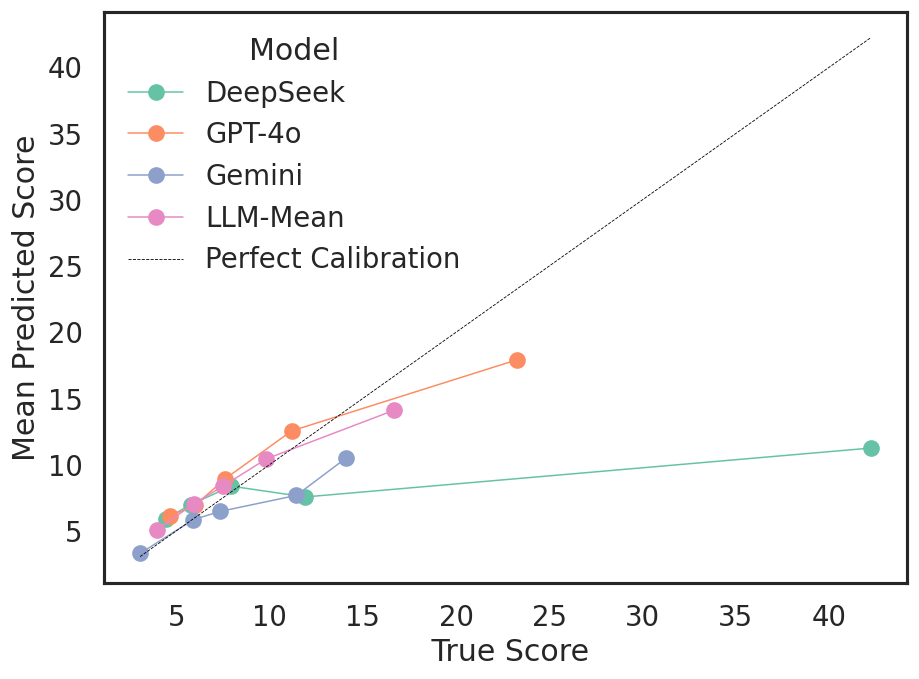

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# Prepare data
# df_all must contain: y_true, y_pred, Model
# -----------------------------------------------

# Bin true scores into deciles (you can change to 5 bins if needed)
df_all["true_bin"] = pd.qcut(df_all["y_true"], q=5, duplicates="drop")

# Compute mean true score + mean predicted score within each bin and model
calib_df = (
    df_all.groupby(["Model", "true_bin"])
    .agg(
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean")
    )
    .reset_index()
)

# -----------------------------------------------
# Plot calibration curve
# -----------------------------------------------

sns.set(style="white", context="talk", palette="Set2")
plt.figure(figsize=(8, 6))

# One calibration curve per model
for model in calib_df["Model"].unique():
    temp = calib_df[calib_df["Model"] == model]
    plt.plot(
        temp["mean_true"],
        temp["mean_pred"],
        marker="o",
        linewidth=0.9,
        label=model
    )

# Identity line (perfect mimicry)
min_val = calib_df["mean_true"].min()
max_val = calib_df["mean_true"].max()
plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", color="black", linewidth=0.5,
         label="Perfect Calibration")

plt.xlabel(" True Score")
plt.ylabel("Mean Predicted Score")
plt.title("")
plt.legend(title="Model")
plt.tight_layout()

plt.savefig("calibration_curve_panel_3E.png", dpi=300, bbox_inches="tight")
plt.show()
